Mounted at /content/drive
DATASET INFORMATION
Shape : (21263, 82)

Total Features : 81

Train Shape      : (17010, 81)
Validation Shape : (2126, 81)
Test Shape       : (2127, 81)


VALIDATION RESULTS
Validation MAE   : 7.4625
Validation MSE   : 149.0639
Validation RMSE  : 12.2092
Validation R²    : 0.8725


TEST RESULTS
Test MAE         : 7.2691
Test MSE         : 143.1735
Test RMSE        : 11.9655
Test R²          : 0.8736
Adjusted R²      : 0.8685
MAPE             : 1.2164


FINAL RESULT TABLE
           Model  Validation RMSE  Validation R²  Test RMSE  Test R²
0  Decision Tree          12.2092         0.8725    11.9655   0.8736


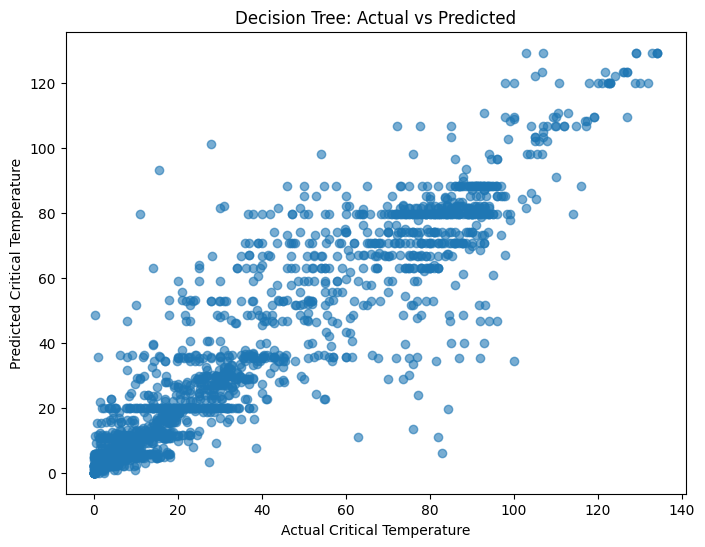



FEATURE IMPORTANCE
                            Feature  Importance
67        range_ThermalConductivity    0.583138
64    wtd_gmean_ThermalConductivity    0.134708
39                      std_Density    0.030155
78                wtd_range_Valence    0.018827
74                wtd_gmean_Valence    0.018613
8             wtd_range_atomic_mass    0.017785
27              range_atomic_radius    0.016627
33                    gmean_Density    0.014765
70      wtd_std_ThermalConductivity    0.012564
65      entropy_ThermalConductivity    0.012409
50         wtd_std_ElectronAffinity    0.011984
31                     mean_Density    0.011949
35                  entropy_Density    0.008961
18                    wtd_range_fie    0.008660
72                 wtd_mean_Valence    0.006603
66  wtd_entropy_ThermalConductivity    0.006527
9                   std_atomic_mass    0.006447
36              wtd_entropy_Density    0.004228
4             wtd_gmean_atomic_mass    0.003954
44       wtd_gmean_

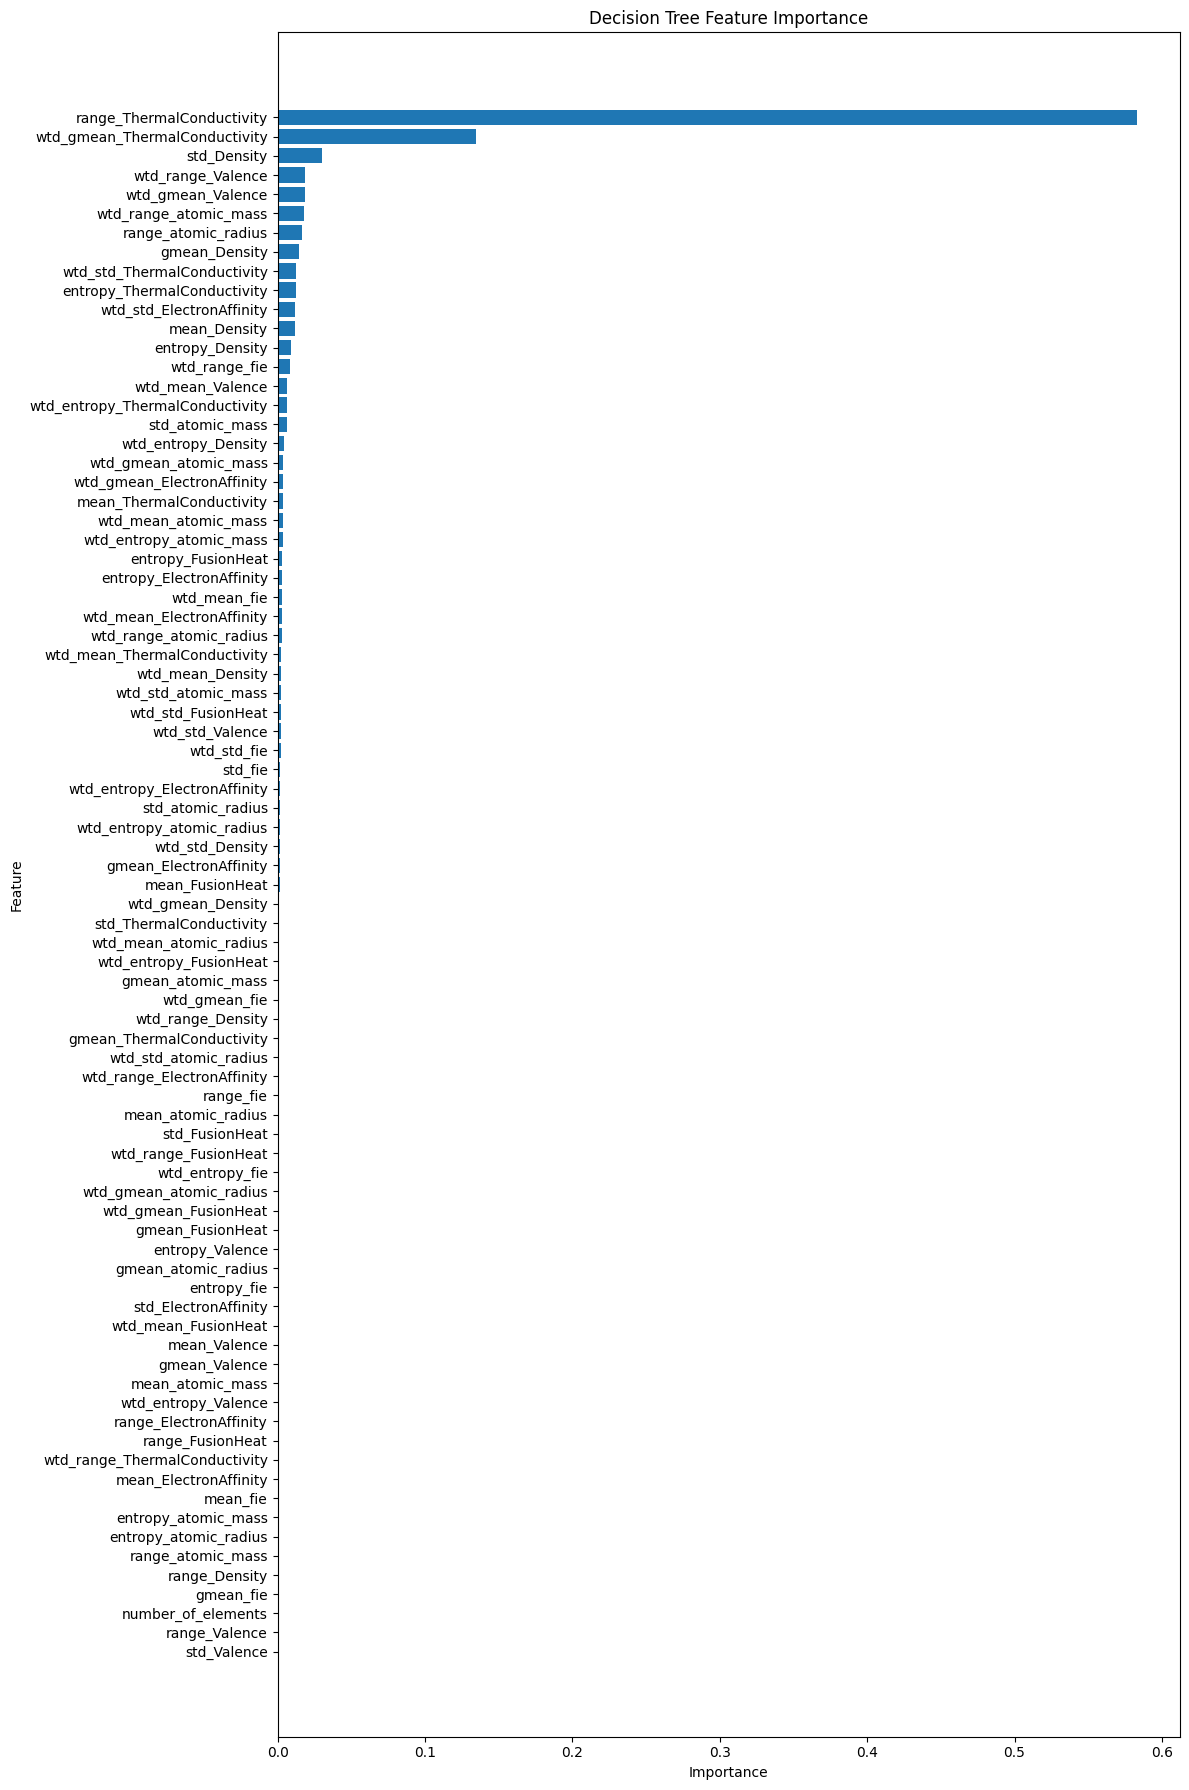

In [1]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# DECISION TREE REGRESSION
# GOOGLE DRIVE VERSION
# ============================================================

# ============================================================
# 1. CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# 3. LOAD DATASET
# ============================================================

file_path = "/content/drive/MyDrive/train.csv"

df = pd.read_csv(file_path)

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Shape :", df.shape)

# ============================================================
# 4. INPUT AND OUTPUT
# ============================================================

target = "critical_temp"

X = df.drop(columns=[target])
y = df[target]

print("\nTotal Features :", X.shape[1])

# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# 80% Train
# 10% Validation
# 10% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nTrain Shape      :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Test Shape       :", X_test.shape)

# ============================================================
# 7. DECISION TREE MODEL
# ============================================================

model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 8. VALIDATION PREDICTIONS
# ============================================================

y_val_pred = model.predict(X_val)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

# ============================================================
# 9. TEST PREDICTIONS
# ============================================================

y_test_pred = model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

test_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred
)

# ============================================================
# 10. ADJUSTED R²
# ============================================================

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1 - test_r2) * (n - 1))
    /
    (n - p - 1)
)

# ============================================================
# 11. VALIDATION RESULTS
# ============================================================

print("\n")
print("="*60)
print("VALIDATION RESULTS")
print("="*60)

print(f"Validation MAE   : {val_mae:.4f}")
print(f"Validation MSE   : {val_mse:.4f}")
print(f"Validation RMSE  : {val_rmse:.4f}")
print(f"Validation R²    : {val_r2:.4f}")

# ============================================================
# 12. TEST RESULTS
# ============================================================

print("\n")
print("="*60)
print("TEST RESULTS")
print("="*60)

print(f"Test MAE         : {test_mae:.4f}")
print(f"Test MSE         : {test_mse:.4f}")
print(f"Test RMSE        : {test_rmse:.4f}")
print(f"Test R²          : {test_r2:.4f}")
print(f"Adjusted R²      : {adj_r2:.4f}")
print(f"MAPE             : {test_mape:.4f}")

# ============================================================
# 13. FINAL RESULT TABLE
# ============================================================

results = pd.DataFrame({
    "Model":["Decision Tree"],
    "Validation RMSE":[round(val_rmse,4)],
    "Validation R²":[round(val_r2,4)],
    "Test RMSE":[round(test_rmse,4)],
    "Test R²":[round(test_r2,4)]
})

print("\n")
print("="*70)
print("FINAL RESULT TABLE")
print("="*70)

print(results)

# ============================================================
# 14. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance.head(20))

# ============================================================
# 16. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12,18))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()